<a href="https://colab.research.google.com/github/adrian-ai-salud/EstadisticaParaSanitarios/blob/master/An%C3%A1lisis_estudo_Soraya.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🔹 Celda 1 — Cargar el archivo
Abre un diálogo para subir el CSV exportado del formulario y lo carga en una tabla de datos (`df`). Toma automáticamente el nombre del archivo subido, así que no hay que escribir la ruta a mano. Al terminar debe mostrar el tamaño `(92, 24)` y las primeras filas.

In [ ]:
# === Celda 1: subir y cargar el CSV ===
import pandas as pd
import numpy as np
from google.colab import files

subido = files.upload()                 # selecciona el archivo .csv en el diálogo
ruta = next(iter(subido))               # toma el nombre del archivo subido (sea cual sea)

df = pd.read_csv(ruta, encoding='utf-8')
print("Forma:", df.shape)               # esperado: (92, 24)
df.head(3)

Saving Evaluación  de la valoración previa y posterior a la aplicación de la terapia compresiva  (respuestas) - Respuestas de formulario 1.csv to Evaluación  de la valoración previa y posterior a la aplicación de la terapia compresiva  (respuestas) - Respuestas de formulario 1.csv
Forma: (92, 24)


,Marca temporal,He leído la información proporcionada y acepto participar libremente en este estudio,Edad,Sexo,Área sanitaria en la que trabaja,Tiempo trabajado en atención primaria,Tipo de contrato,¿Conoce la etiología de la lesión antes de aplicar la terapia compresiva?,¿Revisa la historia clínica del paciente antes de aplicar la terapia compresiva?,¿Realiza la palpación de pulsos antes de la aplicación de la terapia compresiva?,...,¿Valora la tolerancia previa del paciente a la terapia compresiva? En el supesto de que el paciente haya usado con anterioridad terapia compresiva. (respuesta múltiple),Técnica (respuesta mútiple),"¿Realiza protección de zonas de fricción mediante la colocación de tubulares, previa a la aplicación de la terapia compresiva?",¿Realiza homogenización de perímetros previa a la aplicación de la terapia compresiva?,"¿Realiza protección de zonas de hiperpresión (cresta tibial, maléolos...) previa a la aplicación de la terapia compresiva?","Cuando aplica la terapia compresiva, ¿llega con la venda hasta el hueco poplíteo?","Cuando aplica la terapia compresiva, ¿evita la aparición de pliegues (arrugas) longitudinales?","Cuando aplica la terapia compresiva, ¿evita la aparición de pliegues (arrugas) horizontales?","Cuando aplica la terapia compresiva, ¿evita la exposición del talón?","Cuando aplica la terapia compresiva, ¿realiza fijación del vendaje mediante esparadrapo y malla?"
0,31/05/2026 16:14:05,Sí,31-40 años,Hombre,"Área sanitaria de Ourense, Verín e O Barco de ...",11-20 años,Personal fijo,Sí,Sí,Sí,...,Retirada o mantenimento de la terapia compresi...,Técnica en espiral: la venda se superpone una ...,No,Sí,Sí,No,Sí,Sí,Sí,Sí
1,31/05/2026 16:19:29,Sí,20-30 años,Hombre,Área sanitaria de Santiago de Compostela e Bar...,1-5 años,Personal interino,Sí,Sí,Sí,...,Retirada o mantenimento de la terapia compresi...,Técnica en espiral: la venda se superpone una ...,Sí,Sí,Sí,No,Sí,Sí,Sí,Sí
2,31/05/2026 16:46:15,Sí,41-50 años,Mujer,Área sanitaria de Santiago de Compostela e Bar...,6-10 años,Personal fijo,Sí,Sí,Sí,...,Retirada o mantenimento de la terapia compresiva,Técnica en espiral: la venda se superpone una ...,Sí,Sí,Sí,Sí,Sí,Sí,Sí,Sí


### 🔹 Celda 2 — Renombrar columnas y preprocesar las respuestas múltiples
Prepara los datos en cuatro pasos: **(2.1)** pone nombres cortos a las 24 columnas; **(2.2)** convierte la marca temporal a tipo fecha; **(2.3)** define el catálogo de opciones de las 4 variables de respuesta múltiple (sistemas, formación, tolerancia, técnica); **(2.4)** crea una columna binaria 0/1 por cada opción buscando su *firma literal* (evita partir por comas y las trampas de subcadena); **(2.5)** audita el texto libre "Otros" en *técnica* (debe informar de 1 caso).
**Celda imprescindible:** sin ella, los conteos de las variables múltiples salen mal.

In [ ]:
# === Celda 2: renombrado + one-hot de las multirrespuesta ===

# 2.1 Nombres cortos (mismo orden que las 24 columnas originales)
df.columns = ['timestamp','consentimiento','edad','sexo','area','experiencia','contrato',
    'conoce_etiologia','revisa_historia','palpa_pulsos','itb','ecodoppler',
    'sistemas','formacion','tolerancia','tecnica',
    'prot_friccion','homogeniza','prot_hiperpresion','hueco_popliteo',
    'evita_plieg_long','evita_plieg_horiz','evita_talon','fijacion']

# 2.2 Parsear la fecha
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%d/%m/%Y %H:%M:%S', errors='coerce')

# 2.3 Catálogo canónico: (etiqueta corta, firma literal única) por cada variable múltiple
CAT = {
 'sistemas':[('Kit 2 capas AE','Kit de dos capas de alta extensibilidad (AE)'),
             ('Kit 2 capas BE','dos capas de baja extensibiliad (BE)'),
             ('Vendas BE','Vendas de baja extensibilidad (BE)'),
             ('Vendas AE','Vendas de alta extensibilidad (AE)'),
             ('Medias con certif.','Medias con certificación'),
             ('Medias sin certif.','Medias sin certificación'),
             ('Vendaje crepé','Vendaje crepé'),
             ('Velcro con medición','Velcro con medición'),
             ('Velcro sin medición','Velcro sin medición')],
 'formacion':[('Curso form. continuada','Curso de formación continuada'),
              ('Redes sociales','Redes sociales'),
              ('Especialista/Posgrado','Especialista/ Experto/ Posgrado'),
              ('Máster','Máster'),
              ('No aplica','No aplica')],
 'tolerancia':[('Retirada/mantenim.','Retirada o mantenimento'),
               ('Dolor al caminar','Dolor al caminar'),
               ('Dolor nocturno','Dolor nocturno'),
               ('No valoro','No valoro')],
 'tecnica':[('Espiral','Técnica en espiral'),
            ('Espiga','Técnica en espiga'),
            ('Mezclada','Técnica mezclada'),
            ('Sigg y Fischer','Sigg y Fischer')],
}

# 2.4 Crear una columna binaria 0/1 por cada opción
for col, opciones in CAT.items():
    for etiqueta, firma in opciones:
        nueva = f"{col}__{etiqueta}"
        df[nueva] = df[col].str.contains(firma, regex=False, na=False).astype(int)

# 2.5 Auditoría del texto libre "Otros" detectado en 'tecnica' (el ', 50%')
otros_tec = df['tecnica'].dropna().str.strip().str.endswith(', 50%').sum()
print(f"Celdas con texto libre 'Otros' en 'tecnica': {otros_tec}")
print("Preprocesado completado. Columnas binarias creadas:",
      sum(len(v) for v in CAT.values()))

Celdas con texto libre 'Otros' en 'tecnica': 1
Preprocesado completado. Columnas binarias creadas: 22


### 🔹 Celda 3 — Funciones para las tablas
Define dos funciones reutilizables (no imprime nada por sí sola): `tabla_frec()` para variables de respuesta simple (n y %, con orden lógico en edad/experiencia/contrato) y `tabla_multi()` para variables de respuesta múltiple (% calculado sobre respondentes, por lo que suma >100%).

In [ ]:
# === Celda 3: funciones auxiliares ===

ORDEN = {  # orden lógico para variables ordinales
 'edad':['20-30 años','31-40 años','41-50 años','51-60 años','61-70 años'],
 'experiencia':['<1 año','1-5 años','6-10 años','11-20 años','>20 años'],
 'contrato':['Personal fijo','Personal interino','Personal sustituto']}

def tabla_frec(col):
    """Frecuencia y % (sobre válidos) para una variable de respuesta simple."""
    s = df[col]; n = s.notna().sum()
    vc = s.value_counts(dropna=False)
    if col in ORDEN:
        idx = [c for c in ORDEN[col] if c in vc.index] + \
              [c for c in vc.index if c not in ORDEN[col]]
        vc = vc.reindex(idx)
    return pd.DataFrame({'n': vc, '%': (vc/n*100).round(1)})

def tabla_multi(col):
    """Frecuencia y % SOBRE RESPONDENTES para una variable múltiple (suma >100%)."""
    base = df[col].notna().sum()
    filas = [(et, df[col].str.contains(f, regex=False, na=False).sum()) for et, f in CAT[col]]
    out = pd.DataFrame(filas, columns=['opción','n'])
    out['% resp.'] = (out['n']/base*100).round(1)
    return out.sort_values('n', ascending=False).set_index('opción'), base

### 🔹 Celda 4 — Descriptivo de variables simples
Imprime las tablas de frecuencia (n y %) de las variables sociodemográficas, de la valoración vascular previa (marca con ⚠ las constantes: etiología e historia clínica) y de la técnica de aplicación (preguntas Sí/No).

In [ ]:
# === Celda 4: descriptivo univariante (respuesta simple) ===

print("="*55, "\nSOCIODEMOGRÁFICAS (n=92)\n", "="*55)
for c in ['edad','sexo','area','experiencia','contrato']:
    print(f"\n— {c} —"); print(tabla_frec(c).to_string())

print("\n"+"="*55, "\nVALORACIÓN VASCULAR PREVIA\n", "="*55)
for c in ['conoce_etiologia','revisa_historia','palpa_pulsos','itb','ecodoppler']:
    cte = '  ⚠ CONSTANTE (varianza 0)' if df[c].nunique()==1 else ''
    print(f"\n— {c}{cte} —"); print(tabla_frec(c).to_string())

print("\n"+"="*55, "\nTÉCNICA DE APLICACIÓN (Sí/No)\n", "="*55)
for c in ['prot_friccion','homogeniza','prot_hiperpresion','hueco_popliteo',
          'evita_plieg_long','evita_plieg_horiz','evita_talon','fijacion']:
    print(f"\n— {c} —"); print(tabla_frec(c).to_string())

SOCIODEMOGRÁFICAS (n=92)

— edad —
             n     %
edad                
20-30 años  24  26.1
31-40 años  31  33.7
41-50 años  21  22.8
51-60 años  13  14.1
61-70 años   3   3.3

— sexo —
                      n     %
sexo                         
Mujer                75  81.5
Hombre               16  17.4
Prefiero no decirlo   1   1.1

— area —
                                                           n     %
area                                                              
Área sanitaria de Santiago de Compostela e Barbanza       54  58.7
Área sanitaria de Lugo, A Mariña e Monforte de Lemos      12  13.0
Área sanitaria de Coruña e Cee                            10  10.9
Área sanitaria de Vigo                                    10  10.9
Área sanitaria de Pontevedra e o Salnés                    3   3.3
Área sanitaria de Ourense, Verín e O Barco de Valdeorras   2   2.2
Área sanitaria de Ferrol                                   1   1.1

— experiencia —
              n     %
experi

### 🔹 Celda 5 — Descriptivo de variables múltiples
Para sistemas, formación, tolerancia y técnica, muestra cuántos respondentes marcaron cada opción y su % sobre respondentes, además del número medio de opciones marcadas por persona. Recuerda: estos porcentajes **suman más de 100%** a propósito, porque cada persona puede elegir varias opciones.

In [ ]:
# === Celda 5: descriptivo de respuestas múltiples ===

for col in ['sistemas','formacion','tolerancia','tecnica']:
    out, base = tabla_multi(col)
    print(f"\n{'='*55}\n{col.upper()}  (respondentes={base}; el % suma >100 por ser múltiple)\n{'='*55}")
    print(out.to_string())

print("\n— nº de opciones marcadas por persona —")
for col in ['sistemas','formacion','tolerancia','tecnica']:
    cnt = df[col].dropna().apply(lambda cell: sum(f in cell for _, f in CAT[col]))
    print(f"  {col:12s}: media={cnt.mean():.2f}  (rango {cnt.min()}–{cnt.max()})")


SISTEMAS  (respondentes=92; el % suma >100 por ser múltiple)
                      n  % resp.
opción                          
Kit 2 capas AE       76     82.6
Vendas BE            60     65.2
Medias sin certif.   56     60.9
Medias con certif.   55     59.8
Vendaje crepé        27     29.3
Kit 2 capas BE       25     27.2
Vendas AE            17     18.5
Velcro con medición  15     16.3
Velcro sin medición   2      2.2

FORMACION  (respondentes=91; el % suma >100 por ser múltiple)
                         n  % resp.
opción                             
Curso form. continuada  78     85.7
Redes sociales          25     27.5
Especialista/Posgrado   20     22.0
No aplica                9      9.9
Máster                   3      3.3

TOLERANCIA  (respondentes=91; el % suma >100 por ser múltiple)
                     n  % resp.
opción                         
Retirada/mantenim.  83     91.2
Dolor al caminar    60     65.9
Dolor nocturno      58     63.7
No valoro            5      5.5

TEC

### 🔹 Celda 6 — Preparar variables para el bivariante
Por el N pequeño y la dispersión, se **colapsan** los predictores muy desbalanceados para que las pruebas tengan potencia: área → *Santiago-Barbanza vs Resto*; contrato → *Fijo vs No fijo*; experiencia → *≤5 vs >5 años* (y se conserva una versión **ordinal** de edad y experiencia para la prueba de tendencia). Se binarizan los desenlaces (Sí=1). Se seleccionan como desenlaces formales solo los que tienen variabilidad suficiente (`ecodoppler`, `hueco_popliteo`, `fijacion`); los casi-constantes quedan fuera del test porque no aportan potencia.

In [ ]:
# === Celda 6: recodificaciones para el análisis bivariante ===
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency, norm
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests

# Desenlaces binarios (Sí=1)
df['out_eco']   = (df['ecodoppler']     == 'Sí').astype(int)
df['out_hueco'] = (df['hueco_popliteo'] == 'Sí').astype(int)
df['out_fij']   = (df['fijacion']       == 'Sí').astype(int)

# Predictores colapsados a 2 niveles (potencia)
df['area_bin']     = np.where(df['area'].str.contains('Santiago'), 'Santiago-Barbanza', 'Resto')
df['contrato_bin'] = np.where(df['contrato'] == 'Personal fijo', 'Fijo', 'No fijo')
df['exp_bin']      = np.where(df['experiencia'].isin(['<1 año','1-5 años']), '≤5 años', '>5 años')
df['sexo_2']       = df['sexo'].where(df['sexo'].isin(['Mujer','Hombre']))  # excluye 'Prefiero no decirlo' (n=1)

# Versiones ordinales para la prueba de tendencia
df['exp_ord']  = df['experiencia'].map({'<1 año':1,'1-5 años':2,'6-10 años':3,'11-20 años':4,'>20 años':5})
df['edad_ord'] = df['edad'].map({'20-30 años':1,'31-40 años':2,'41-50 años':3,'51-60 años':4,'61-70 años':5})

predictores_2x2 = ['exp_bin','area_bin','contrato_bin','sexo_2']
predictores_ord = ['edad_ord','exp_ord']
desenlaces      = ['out_eco','out_hueco','out_fij']
print("Variables del bivariante listas.")

Variables del bivariante listas.


### 🔹 Celda 7 — Motor bivariante (elige la prueba según los supuestos)
Función `bivariante(pred, out)` que, para cada par, construye la tabla de contingencia y **calcula las frecuencias esperadas**. Decide la prueba automáticamente: si la tabla es 2×2 y alguna esperada <5 → **Fisher exacto**; si ≥5 → **chi² de Pearson**; si el predictor tiene >2 niveles → **chi² + V de Cramér** y avisa si hay que colapsar (celdas con esperado <5). Devuelve siempre: prueba usada, esperado mínimo (control del supuesto), p-valor, tamaño del efecto con IC95% (**OR** en 2×2, **V de Cramér** en r×c) y las proporciones por grupo con **IC95% de Wilson**.

In [ ]:
# === Celda 7: motor bivariante con chequeo de supuestos ===
def v_cramer(chi2v, n, r, c):
    return np.sqrt(chi2v / (n * (min(r, c) - 1)))

def bivariante(pred, out):
    d  = df[[pred, out]].dropna()
    ct = pd.crosstab(d[pred], d[out])
    chi2v, p_chi, dof, exp = chi2_contingency(ct, correction=False)
    min_esp = exp.min()

    if ct.shape == (2, 2):                      # ---- camino 2x2 ----
        niv = list(ct.index)
        tab = ct.reindex(columns=[1, 0]).values  # [evento, no-evento]
        if min_esp < 5:
            _, p = fisher_exact(tab); test = 'Fisher exacto'
        else:
            p = p_chi; test = 'Chi² Pearson'
        t = Table2x2(tab, shift_zeros=True)     # Haldane si hay celda 0
        OR = t.oddsratio; lo, hi = t.oddsratio_confint()
        efecto = f"OR={OR:.2f} (IC95 {lo:.2f}-{hi:.2f})"
        props = []
        for i, nv in enumerate(niv):
            ev, ntot = tab[i, 0], tab[i].sum()
            wlo, whi = proportion_confint(ev, ntot, method='wilson')
            props.append(f"{nv}: {ev/ntot*100:.1f}% (IC95 {wlo*100:.1f}-{whi*100:.1f})")
        detalle = " | ".join(props)
    else:                                        # ---- camino r×c ----
        p = p_chi
        aviso = '' if min_esp >= 5 else f" ⚠ {(exp<5).mean()*100:.0f}% celdas E<5: colapsar"
        test = 'Chi² Pearson' + aviso
        efecto = f"V de Cramér={v_cramer(chi2v, ct.values.sum(), *ct.shape):.3f}"
        detalle = '—'

    return dict(pred=pred, out=out, test=test, min_esp=round(min_esp, 2),
                p=p, efecto=efecto, detalle=detalle)

### 🔹 Celda 8 — Tendencia para predictores ordinales (Cochran-Armitage)
Para edad y experiencia (variables **ordinales**) se contrasta si existe una **tendencia monótona** en la proporción del desenlace al avanzar de categoría (p. ej. a más experiencia, ¿más uso de eco-doppler?). Es más potente que un chi² genérico porque aprovecha el orden. Pondera cada categoría por su puntuación ordinal; el estadístico `z` resultante elevado al cuadrado se distribuye como χ² con 1 grado de libertad. Un `z` positivo indica tendencia creciente; negativo, decreciente.

In [ ]:
# === Celda 8: prueba de tendencia de Cochran-Armitage ===
def cochran_armitage(pred_ord, out):
    d = df[[pred_ord, out]].dropna()
    g = d.groupby(pred_ord)[out].agg(['sum', 'count'])
    t, a, n = g.index.values.astype(float), g['sum'].values, g['count'].values
    N, R1 = n.sum(), a.sum(); R2 = N - R1
    T   = np.sum(t * (a - n * R1 / N))
    var = (R1 * R2 / N) * (np.sum(n * t**2) - (np.sum(n * t))**2 / N)
    z   = T / np.sqrt(var); p = 2 * (1 - norm.cdf(abs(z)))
    return dict(pred=pred_ord, out=out, test='Cochran-Armitage (tendencia)',
                z=round(z, 3), p=p)

### 🔹 Celda 9 — Ejecutar todos los contrastes y corregir por multiplicidad
Recorre todos los pares predictor × desenlace, reúne los resultados en una tabla y aplica la **corrección FDR de Benjamini-Hochberg** (`q_BH`): como se realizan muchos contrastes, sin corregir aumentaría el riesgo de falsos positivos. Se interpretan como robustos los resultados con **q_BH < 0,05**. La columna `min_esp` permite verificar de un vistazo que el supuesto del chi² se cumplió (o que se usó Fisher). Recuerda: con N=92 los IC son anchos; un resultado no significativo refleja sobre todo **baja potencia**, no ausencia de efecto.

In [ ]:
# === Celda 9: barrido bivariante + FDR ===
res = [bivariante(p, o) for p in predictores_2x2 for o in desenlaces]
R = pd.DataFrame(res)
R['q_BH'] = multipletests(R['p'], method='fdr_bh')[1]
R = R.sort_values('p')

pd.set_option('display.width', 220, 'display.max_colwidth', 70)
print("===== BIVARIANTE (predictores categóricos) =====")
print(R[['pred','out','test','min_esp','efecto','p','q_BH']].to_string(index=False))

print("\n===== TENDENCIA ORDINAL (Cochran-Armitage) =====")
rc = [cochran_armitage(p, o) for p in predictores_ord for o in desenlaces]
print(pd.DataFrame(rc).sort_values('p').to_string(index=False))

# Detalle de proporciones de un par concreto (cámbialo a voluntad)
print("\nDetalle proporciones — contrato_bin vs out_hueco:")
print(next(r['detalle'] for r in res if r['pred']=='contrato_bin' and r['out']=='out_hueco'))

===== BIVARIANTE (predictores categóricos) =====
        pred       out          test  min_esp                   efecto        p     q_BH
contrato_bin out_hueco  Chi² Pearson    14.41 OR=0.28 (IC95 0.11-0.68) 0.003989 0.047871
    area_bin out_hueco  Chi² Pearson    14.04 OR=2.24 (IC95 0.91-5.51) 0.076103 0.339952
      sexo_2 out_hueco  Chi² Pearson     5.98 OR=0.39 (IC95 0.13-1.17) 0.085391 0.339952
     exp_bin   out_eco  Chi² Pearson     9.75 OR=2.15 (IC95 0.83-5.60) 0.113317 0.339952
     exp_bin out_hueco  Chi² Pearson    14.41 OR=0.61 (IC95 0.26-1.44) 0.258182 0.619636
contrato_bin   out_eco  Chi² Pearson     9.75 OR=0.65 (IC95 0.25-1.74) 0.393864 0.762891
    area_bin   out_eco  Chi² Pearson     9.50 OR=1.43 (IC95 0.55-3.69) 0.463258 0.762891
      sexo_2   out_eco Fisher exacto     3.87 OR=1.55 (IC95 0.47-5.08) 0.523907 0.762891
      sexo_2   out_fij Fisher exacto     3.16 OR=1.90 (IC95 0.39-9.23) 0.729724 0.762891
     exp_bin   out_fij  Chi² Pearson     7.63 OR=1.20 (IC95 0

### 🔹 Celda 10 — Tamaño muestral y nº de predictores admisibles (EPV)
No hubo cálculo muestral a priori, así que la potencia se gestiona de forma correcta: **no** se calcula "potencia observada" (es una falacia, solo reexpresa el p-valor), sino que (1) se reporta la **precisión** mediante IC y (2) se limita el modelo según los **eventos por variable (EPV)**. La regla: nº de predictores ≤ (eventos de la clase minoritaria)/10. Esta celda calcula los eventos disponibles y, a título ilustrativo, el tamaño que se habría necesitado para detectar el efecto del contrato con 80% de potencia.

In [ ]:
# === Celda 10: EPV y precisión ===
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

for o in ['out_hueco','out_eco']:
    e = int(min(df[o].sum(), (1-df[o]).sum()))
    print(f"{o}: {e} eventos (clase minoritaria) -> EPV10 admite {e//10} predictores")

p1 = df.loc[df.contrato_bin=='No fijo','out_hueco'].mean()
p2 = df.loc[df.contrato_bin=='Fijo','out_hueco'].mean()
n  = NormalIndPower().solve_power(effect_size=abs(proportion_effectsize(p1,p2)),
                                  alpha=0.05, power=0.80, ratio=1.0)
print(f"\nhueco: No fijo={p1:.0%} vs Fijo={p2:.0%} -> n/grupo para 80% potencia ≈ {np.ceil(n):.0f} (total {np.ceil(n)*2:.0f})")

out_hueco: 34 eventos (clase minoritaria) -> EPV10 admite 3 predictores
out_eco: 23 eventos (clase minoritaria) -> EPV10 admite 2 predictores

hueco: No fijo=75% vs Fijo=46% -> n/grupo para 80% potencia ≈ 42 (total 84)


### 🔹 Celda 11 — Regresión logística multivariable (desenlace: hueco poplíteo)
Ajusta un modelo logístico **preespecificado** con tres predictores (contrato, experiencia, área), todos categóricos para evitar el supuesto de linealidad del logit. Reporta la **OR ajustada** de cada variable (OR = e^β) con su **IC95% de Wald** (e^(β±1,96·EE)) y su p-valor. Evalúa el ajuste global con: **test de razón de verosimilitud** (LR = 2·(logL_modelo − logL_nulo), distribuido como χ²), **pseudo-R² de McFadden** (1 − logL_modelo/logL_nulo) y **AUC / estadístico C** (capacidad de discriminación: 0,5 = azar, >0,7 aceptable). Finalmente compara la **OR cruda vs ajustada** del contrato: un cambio >10–20% indicaría confusión por experiencia o área.

In [ ]:
# === Celda 11: modelo logístico multivariable ===
import statsmodels.formula.api as smf, statsmodels.api as sm
from scipy.stats import chi2
from sklearn.metrics import roc_auc_score

# Categorías con referencia explícita (primer nivel = referencia)
df['contrato_bin'] = pd.Categorical(df['contrato_bin'], ['No fijo','Fijo'])
df['exp_bin']      = pd.Categorical(df['exp_bin'],      ['>5 años','≤5 años'])
df['area_bin']     = pd.Categorical(df['area_bin'],     ['Resto','Santiago-Barbanza'])

m    = smf.glm('out_hueco ~ contrato_bin + exp_bin + area_bin', data=df, family=sm.families.Binomial()).fit()
null = smf.glm('out_hueco ~ 1', data=df, family=sm.families.Binomial()).fit()

OR, CI = np.exp(m.params), np.exp(m.conf_int())
tab = pd.DataFrame({'OR_aj': OR.round(2),
                    'IC95': [f"{a:.2f}-{b:.2f}" for a,b in CI.values],
                    'p': m.pvalues.round(4)})
print("=== OR AJUSTADAS ==="); print(tab.to_string())

LR  = 2*(m.llf - null.llf); p_LR = chi2.sf(LR, m.df_model)
R2  = 1 - m.llf/null.llf;   auc  = roc_auc_score(df['out_hueco'], m.predict())
print(f"\nLR global: χ²={LR:.2f}, p={p_LR:.4f} | McFadden R²={R2:.3f} | AUC={auc:.3f} | AIC={m.aic:.1f}")

crudo = smf.glm('out_hueco ~ contrato_bin', data=df, family=sm.families.Binomial()).fit()
print(f"OR contrato (Fijo): cruda={np.exp(crudo.params.iloc[1]):.2f} -> ajustada={np.exp(m.params['contrato_bin[T.Fijo]']):.2f}  (sin confusión relevante)")

=== OR AJUSTADAS ===
                               OR_aj        IC95       p
Intercept                       4.84  1.53-15.36  0.0074
contrato_bin[T.Fijo]            0.28   0.10-0.83  0.0216
exp_bin[T.≤5 años]              0.92   0.31-2.73  0.8847
area_bin[T.Santiago-Barbanza]   0.51   0.20-1.31  0.1619

LR global: χ²=10.49, p=0.0148 | McFadden R²=0.087 | AUC=0.693 | AIC=118.7
OR contrato (Fijo): cruda=0.28 -> ajustada=0.28  (sin confusión relevante)


### 🔹 Celda 12 — Verificación de supuestos del modelo logístico
Comprueba las condiciones que pueden invalidar la inferencia: **(1) Multicolinealidad** vía VIF (= 1/(1−R²_j); VIF>5 problemático), porque predictores muy correlacionados inflan los errores estándar. **(2) Separación** (perfecta o cuasi): se detecta por errores estándar desorbitados; frecuente en muestras pequeñas y sesga las OR. **(3) Observaciones influyentes** mediante distancia de Cook (umbral habitual 4/n). **(4) Calibración** con el test de Hosmer-Lemeshow, que agrupa por deciles de probabilidad predicha y compara observados vs esperados (p>0,05 = buen ajuste; interpretar con cautela por el N pequeño).

In [ ]:
# === Celda 12: diagnósticos ===
from statsmodels.stats.outliers_influence import variance_inflation_factor

# (1) VIF
X = sm.add_constant(pd.get_dummies(df[['contrato_bin','exp_bin','area_bin']], drop_first=True).astype(float))
vif = pd.DataFrame({'var': X.columns, 'VIF': [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]})
print("VIF (colinealidad):"); print(vif[vif['var']!='const'].round(2).to_string(index=False))

# (2) Separación  (3) Influencia
print(f"\nEE máximo = {m.bse.max():.2f}  (un valor enorme indicaría separación)")
cook = m.get_influence().cooks_distance[0]
print(f"Obs. influyentes (Cook > 4/n = {4/len(df):.3f}): {(cook > 4/len(df)).sum()}  -> índices {list(np.where(cook>4/len(df))[0])}")

# (4) Hosmer-Lemeshow
def hosmer_lemeshow(y, p, g=10):
    d = pd.DataFrame({'y': y, 'p': p}).sort_values('p')
    d['dec'] = pd.qcut(d['p'], g, duplicates='drop')
    o = d.groupby('dec')['y'].agg(['sum','count']); e = d.groupby('dec')['p'].sum()
    hl = (((o['sum']-e)**2)/(e*(1-e/o['count']))).sum(); dof = len(o)-2
    return hl, chi2.sf(hl, dof), dof
hl, p_hl, dof = hosmer_lemeshow(df['out_hueco'].values, np.asarray(m.predict()))
print(f"Hosmer-Lemeshow: χ²={hl:.2f}, gl={dof}, p={p_hl:.3f}  (p>0.05 = buena calibración)")

VIF (colinealidad):
                       var  VIF
         contrato_bin_Fijo 1.42
           exp_bin_≤5 años 1.40
area_bin_Santiago-Barbanza 1.05

EE máximo = 0.59  (un valor enorme indicaría separación)
Obs. influyentes (Cook > 4/n = 0.043): 2  -> índices [np.int64(67), np.int64(84)]
Hosmer-Lemeshow: χ²=4.06, gl=5, p=0.541  (p>0.05 = buena calibración)


/tmp/ipykernel_765/2227869112.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  o = d.groupby('dec')['y'].agg(['sum','count']); e = d.groupby('dec')['p'].sum()


### 🔹 Celda 13 — Comprobación de robustez (regresión de Firth)
En muestras pequeñas la regresión logística clásica sesga las OR y falla si hay separación. La **regresión de Firth** aplica una penalización (prior de Jeffreys) que corrige ese sesgo y siempre converge, por lo que sirve de prueba de robustez. Se implementa directamente en numpy (sin paquetes externos, compatible con cualquier versión de Python): ajuste por Newton-Raphson con el término de corrección de Firth sobre los elementos diagonales de la matriz hat. Si las OR de Firth coinciden en magnitud y dirección con las del modelo clásico, el efecto es sólido. *Nota:* los IC mostrados son de tipo Wald penalizado; R (`logistf`) usa IC de verosimilitud perfilada, prácticamente equivalentes para este fin.

In [ ]:
# === Celda 13: robustez con Firth (numpy puro, sin dependencias) ===
from scipy.stats import norm

def firth_logistic(X, y, max_iter=200, tol=1e-8):
    """Regresión logística de Firth (reducción de sesgo, prior de Jeffreys)."""
    n, p = X.shape
    beta = np.zeros(p)
    for _ in range(max_iter):
        eta = X @ beta
        pi  = 1/(1+np.exp(-eta))
        W   = pi*(1-pi)
        I_inv = np.linalg.inv((X.T * W) @ X)          # inversa de la info de Fisher
        Xs  = X * np.sqrt(W)[:, None]
        h   = np.einsum('ij,jk,ik->i', Xs, I_inv, Xs) # diagonal de la matriz hat
        U   = X.T @ (y - pi + h*(0.5 - pi))           # score modificado de Firth
        step = I_inv @ U
        beta = beta + step
        if np.max(np.abs(step)) < tol:
            break
    eta = X @ beta; pi = 1/(1+np.exp(-eta)); W = pi*(1-pi)
    se = np.sqrt(np.diag(np.linalg.inv((X.T * W) @ X)))  # EE penalizado (Wald)
    return beta, se

# Matriz de diseño con las mismas referencias que el modelo clásico
D = pd.get_dummies(df[['contrato_bin','exp_bin','area_bin']], drop_first=True).astype(float)
X = np.column_stack([np.ones(len(df)), D.values])
y = df['out_hueco'].values.astype(float)

beta, se = firth_logistic(X, y)
nombres = ['Intercepto'] + list(D.columns)
print("=== OR de Firth (robustez) ===")
for nm, b, s in zip(nombres, beta, se):
    p_val = 2*(1 - norm.cdf(abs(b/s)))
    print(f"  {nm:30s} OR={np.exp(b):.2f}  (IC95 {np.exp(b-1.96*s):.2f}-{np.exp(b+1.96*s):.2f})  p={p_val:.4f}")

=== OR de Firth (robustez) ===
  Intercepto                     OR=4.42  (IC95 1.42-13.76)  p=0.0104
  contrato_bin_Fijo              OR=0.30  (IC95 0.11-0.88)  p=0.0282
  exp_bin_≤5 años                OR=0.95  (IC95 0.32-2.77)  p=0.9182
  area_bin_Santiago-Barbanza     OR=0.53  (IC95 0.20-1.35)  p=0.1814


### 🔹 Celda 14 — Índice de adherencia y análisis de ítems
Construye una puntuación 0–11 sumando los ítems en los que "Sí" = buena práctica. Se **excluyen los 2 ítems constantes** (etiología e historia, al 100%) porque no discriminan. Para cada ítem se calcula: **dificultad** (p = proporción que lo realiza correctamente) y **correlación ítem-resto** (punto-biserial entre el ítem y la suma de los demás; valores bajos o negativos señalan ítems que no "van con" el resto). La **consistencia interna** se mide con **KR-20** (equivalente a Cronbach para ítems dicotómicos): `KR20 = k/(k-1)·(1 − Σpᵢqᵢ/σ²_total)`. Un KR-20 alto (>0,7) indicaría una escala coherente; un valor bajo indica que los ítems son conductas independientes, por lo que el índice debe leerse como **recuento clínico de pasos**, no como escala fiable.

In [ ]:
# === Celda 14: índice de adherencia + análisis de ítems + KR-20 ===
items = ['palpa_pulsos','itb','ecodoppler','prot_friccion','homogeniza','prot_hiperpresion',
         'hueco_popliteo','evita_plieg_long','evita_plieg_horiz','evita_talon','fijacion']

B = df[items].apply(lambda s: (s == 'Sí').astype('float'))
B[df[items].isna()] = np.nan
df['adherencia'] = B.sum(axis=1).where(B.notna().all(axis=1))   # solo casos completos
comp = B.dropna()
print(f"Ítems={len(items)} | casos completos={len(comp)} (descartado {len(df)-len(comp)} por NA)\n")

print(f"{'Ítem':20s} p(correcto)  ítem-resto")
for it in items:
    rest = comp.drop(columns=it).sum(axis=1)
    r = np.corrcoef(comp[it], rest)[0, 1]
    print(f"{it:20s}   {comp[it].mean():.2f}        {r:+.2f}")

k = len(items); total = comp.sum(axis=1); p_i = comp.mean()
kr20 = (k/(k-1)) * (1 - (p_i*(1-p_i)).sum() / total.var(ddof=1))
print(f"\nKR-20 (consistencia interna) = {kr20:.3f}")

Ítems=11 | casos completos=91 (descartado 1 por NA)

Ítem                 p(correcto)  ítem-resto
palpa_pulsos           0.99        +0.21
itb                    0.90        +0.03
ecodoppler             0.25        +0.02
prot_friccion          0.91        +0.20
homogeniza             0.90        +0.33
prot_hiperpresion      0.92        +0.33
hueco_popliteo         0.63        -0.08
evita_plieg_long       0.99        +0.02
evita_plieg_horiz      0.97        +0.10
evita_talon            0.95        -0.03
fijacion               0.81        +0.05

KR-20 (consistencia interna) = 0.250


### 🔹 Celda 15 — Distribución del índice de adherencia
Describe la puntuación con los estadísticos adecuados a una variable **no normal y con techo**: mediana e IQR (no media±DT), asimetría y prueba de normalidad de **Shapiro-Wilk** (p<0,05 = no normal). Esto justifica que, más adelante, los contrastes sean **no paramétricos**. El histograma muestra el sesgo a la izquierda (la mayoría puntúa alto).

n=91 | media=9.22 DT=1.14 | mediana=9 IQR=9-10 | rango=6-11
asimetría=-0.93 | Shapiro-Wilk p=0.0000  (p<0.05 = no normal)


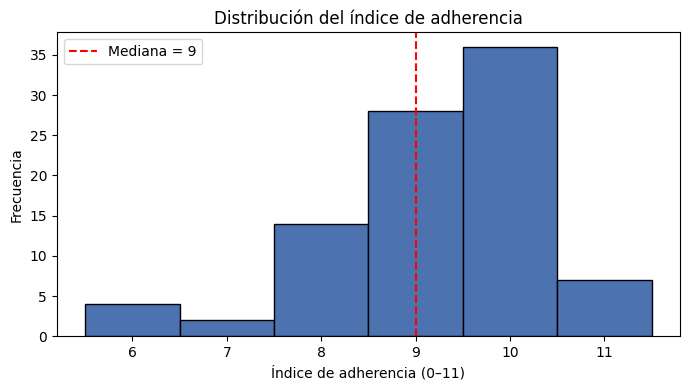

In [ ]:
# === Celda 15: distribución del índice ===
import matplotlib.pyplot as plt
from scipy.stats import skew, shapiro

s = df['adherencia'].dropna()
print(f"n={len(s)} | media={s.mean():.2f} DT={s.std():.2f} | mediana={s.median():.0f} "
      f"IQR={s.quantile(.25):.0f}-{s.quantile(.75):.0f} | rango={int(s.min())}-{int(s.max())}")
print(f"asimetría={skew(s):.2f} | Shapiro-Wilk p={shapiro(s)[1]:.4f}  (p<0.05 = no normal)")

plt.figure(figsize=(7,4))
plt.hist(s, bins=np.arange(5.5, 12.5, 1), edgecolor='black', color='#4C72B0')
plt.axvline(s.median(), color='red', ls='--', label=f'Mediana = {s.median():.0f}')
plt.xlabel('Índice de adherencia (0–11)'); plt.ylabel('Frecuencia')
plt.title('Distribución del índice de adherencia'); plt.legend(); plt.tight_layout(); plt.show()

### 🔹 Celda 16 — Contrastes sobre el índice y modelo ajustado
Como el índice no es normal, el bivariante usa la **U de Mann-Whitney** (no asume normalidad; compara la distribución entre dos grupos) y se reportan **medianas con IQR**. Para el efecto ajustado se ajusta una **regresión lineal (OLS) con errores estándar robustos HC3**, que protege frente a heterocedasticidad; cada β es el cambio en el nº de pasos correctos. Se **verifican los supuestos**: normalidad de los residuos (Shapiro-Wilk) y homocedasticidad (**Breusch-Pagan**, p<0,05 = varianza no constante). Dado que el desenlace es un recuento acotado y sesgado, el OLS se interpreta con cautela; una alternativa más fiel sería un GLM de Poisson sobre el nº de *errores* (11 − adherencia).

In [ ]:
# === Celda 16: bivariante no paramétrico + OLS robusto ===
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

df['form_posgrado'] = np.where(df['formacion'].fillna('').str.contains('Especialista/ Experto/ Posgrado'), 'Sí', 'No')
d = df.dropna(subset=['adherencia'])

print("=== Mann-Whitney sobre el índice ===")
for p in ['contrato_bin','exp_bin','area_bin','form_posgrado']:
    niv = list(d.groupby(p).groups)
    a, b = d[d[p]==niv[0]]['adherencia'], d[d[p]==niv[1]]['adherencia']
    pv = mannwhitneyu(a, b).pvalue
    md = {n: f"{d[d[p]==n]['adherencia'].median():.0f} (IQR {d[d[p]==n]['adherencia'].quantile(.25):.0f}-{d[d[p]==n]['adherencia'].quantile(.75):.0f})" for n in niv}
    print(f"  {p:14s} {niv[0]}: {md[niv[0]]}  vs  {niv[1]}: {md[niv[1]]}   p={pv:.3f}")

print("\n=== OLS multivariable (EE robustos HC3) ===")
m_ols = smf.ols('adherencia ~ C(contrato_bin)+C(exp_bin)+C(area_bin)+C(form_posgrado)', data=d).fit(cov_type='HC3')
co = pd.DataFrame({'β': m_ols.params.round(2),
                   'IC95': [f"{a:.2f}, {b:.2f}" for a,b in m_ols.conf_int().values],
                   'p': m_ols.pvalues.round(3)})
print(co.to_string()); print(f"R²={m_ols.rsquared:.3f} | R²aj={m_ols.rsquared_adj:.3f} | F p={m_ols.f_pvalue:.3f}")
print(f"\nSupuestos -> Shapiro residuos p={shapiro(m_ols.resid)[1]:.4f} | "
      f"Breusch-Pagan p={het_breuschpagan(m_ols.resid, m_ols.model.exog)[1]:.3f}")

=== Mann-Whitney sobre el índice ===
  contrato_bin   No fijo: 10 (IQR 9-10)  vs  Fijo: 9 (IQR 8-10)   p=0.051
  exp_bin        >5 años: 9 (IQR 8-10)  vs  ≤5 años: 9 (IQR 9-10)   p=0.829
  area_bin       Resto: 10 (IQR 9-10)  vs  Santiago-Barbanza: 9 (IQR 8-10)   p=0.261
  form_posgrado  No: 9 (IQR 9-10)  vs  Sí: 9 (IQR 9-10)   p=0.932

=== OLS multivariable (EE robustos HC3) ===
                                     β         IC95      p
Intercept                         9.57  8.93, 10.20  0.000
C(contrato_bin)[T.Fijo]          -0.39  -1.05, 0.26  0.241
C(exp_bin)[T.≤5 años]            -0.02  -0.71, 0.67  0.958
C(area_bin)[T.Santiago-Barbanza] -0.29  -0.78, 0.19  0.239
C(form_posgrado)[T.Sí]           -0.01  -0.55, 0.54  0.983
R²=0.050 | R²aj=0.006 | F p=0.337

Supuestos -> Shapiro residuos p=0.0006 | Breusch-Pagan p=0.060


/tmp/ipykernel_765/3001665800.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  niv = list(d.groupby(p).groups)
/tmp/ipykernel_765/3001665800.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  niv = list(d.groupby(p).groups)
/tmp/ipykernel_765/3001665800.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  niv = list(d.groupby(p).groups)


### 🔹 Celda 17 — Hipótesis formación → práctica: variables
Define la **exposición**: "formación universitaria avanzada" = haber marcado *Especialista/Experto/Posgrado* o *Máster* (reutiliza las columnas binarias creadas en la Celda 2). Define los **desenlaces de práctica**: valoración (ITB, eco-doppler), corrección técnica (hueco poplíteo), y dos recuentos de repertorio (nº de técnicas y nº de sistemas que maneja). El índice de adherencia ya viene de la Celda 14. La hipótesis es direccional: a más formación, mejor práctica.

In [ ]:
# === Celda 17: exposición (formación avanzada) y desenlaces ===
df['form_avanzada'] = np.where(
    (df['formacion__Especialista/Posgrado'] == 1) | (df['formacion__Máster'] == 1), 'Sí', 'No')
print("Formación avanzada:", df['form_avanzada'].value_counts().to_dict())

# Desenlaces binarios (Sí = práctica recomendada)
for o in ['itb', 'ecodoppler', 'hueco_popliteo']:
    df['o_' + o] = (df[o] == 'Sí').astype(int)

# Recuentos de repertorio (a partir del one-hot de la Celda 2)
df['n_tecnicas'] = df[[c for c in df.columns if c.startswith('tecnica__')]].sum(axis=1)
df['n_sistemas'] = df[[c for c in df.columns if c.startswith('sistemas__')]].sum(axis=1)
print("Desenlaces listos.")

Formación avanzada: {'No': 71, 'Sí': 21}
Desenlaces listos.


### 🔹 Celda 18 — Formación avanzada vs práctica
Aplica el mismo motor riguroso: para los desenlaces **binarios**, tabla 2×2 con elección automática **Fisher/chi²** según las frecuencias esperadas, **OR** (odds de buena práctica en formados vs no formados) con **IC95%**, y **corrección FDR** por las comparaciones múltiples. Para los **recuentos y el índice** (no normales), **U de Mann-Whitney** con medianas e IQR. Clave de lectura: con solo 21 formados la potencia es baja, así que un resultado nulo con **IC anchos** significa "no podemos descartar efectos moderados", no "no hay efecto". Por eso se reporta el efecto y su IC, no solo el p-valor.

In [ ]:
# === Celda 18: análisis formación → práctica ===
from scipy.stats import fisher_exact, chi2_contingency, mannwhitneyu
from statsmodels.stats.contingency_tables import Table2x2
from statsmodels.stats.multitest import multipletests

def biv_exp(exp, out):
    d  = df[[exp, out]].dropna()
    ct = pd.crosstab(d[exp], d[out]).reindex(index=['Sí','No'], columns=[1,0])
    esp = chi2_contingency(ct)[3]
    test, p = ('Fisher', fisher_exact(ct.values)[1]) if esp.min() < 5 \
              else ('Chi²', chi2_contingency(ct.values, correction=False)[1])
    t = Table2x2(ct.values, shift_zeros=True)
    prop = {lvl: f"{ct.loc[lvl,1]}/{ct.loc[lvl].sum()}={ct.loc[lvl,1]/ct.loc[lvl].sum()*100:.0f}%" for lvl in ['Sí','No']}
    return dict(out=out, test=test, p=round(p,3), OR=round(t.oddsratio,2),
                IC95=f"{t.oddsratio_confint()[0]:.2f}-{t.oddsratio_confint()[1]:.2f}",
                formados=prop['Sí'], no_form=prop['No'])

R = pd.DataFrame([biv_exp('form_avanzada', o) for o in ['o_itb','o_ecodoppler','o_hueco_popliteo']])
R['q_BH'] = multipletests(R['p'], method='fdr_bh')[1].round(3)
print("=== Desenlaces binarios (OR = formados vs no formados) ===")
print(R.to_string(index=False))

print("\n=== Recuentos e índice (Mann-Whitney) ===")
for o in ['n_tecnicas','n_sistemas','adherencia']:
    d = df.dropna(subset=[o]); a = d[d.form_avanzada=='Sí'][o]; b = d[d.form_avanzada=='No'][o]
    print(f"  {o:11s} formados med={a.median():.0f} (IQR {a.quantile(.25):.0f}-{a.quantile(.75):.0f})  "
          f"vs no={b.median():.0f} (IQR {b.quantile(.25):.0f}-{b.quantile(.75):.0f})  p={mannwhitneyu(a,b).pvalue:.3f}")

=== Desenlaces binarios (OR = formados vs no formados) ===
             out   test     p   OR      IC95  formados   no_form  q_BH
           o_itb Fisher 1.000 1.04 0.20-5.43 19/21=90% 64/71=90%   1.0
    o_ecodoppler   Chi² 0.886 0.92 0.29-2.87  5/21=24% 18/71=25%   1.0
o_hueco_popliteo   Chi² 0.902 0.94 0.34-2.56 13/21=62% 45/71=63%   1.0

=== Recuentos e índice (Mann-Whitney) ===
  n_tecnicas  formados med=1 (IQR 1-2)  vs no=1 (IQR 1-2)  p=0.913
  n_sistemas  formados med=4 (IQR 3-5)  vs no=3 (IQR 2-4)  p=0.323
  adherencia  formados med=9 (IQR 9-10)  vs no=9 (IQR 9-10)  p=0.617


### 🔹 Celda 19 — Forest plot del modelo multivariable
Representa las **OR ajustadas** de cada predictor del modelo logístico (hueco poplíteo) con su **IC95%**, en **escala logarítmica** (lo correcto para razones de odds: hace simétrico el efecto protector y de riesgo). La línea discontinua en OR=1 marca la ausencia de efecto: si el IC la cruza, no hay asociación significativa. La columna derecha muestra el valor numérico. Es la figura que sustituye a la "Tabla 2" en un artículo.

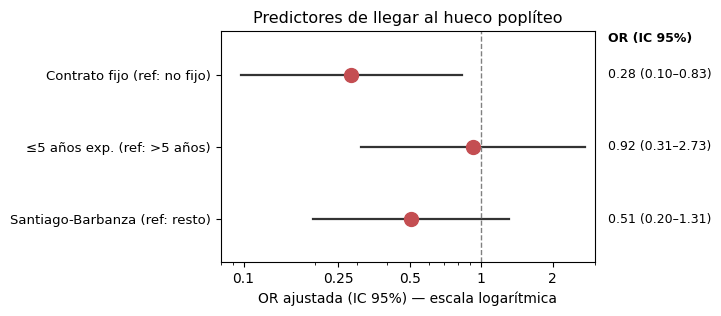

In [ ]:
# === Celda 19 (corregida): forest plot con su propio modelo logístico ===
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf, statsmodels.api as sm

# Reajusta el modelo logístico con nombre propio (evita la colisión con el OLS 'm')
df['contrato_bin'] = pd.Categorical(np.where(df['contrato']=='Personal fijo','Fijo','No fijo'), ['No fijo','Fijo'])
df['exp_bin']      = pd.Categorical(np.where(df['experiencia'].isin(['<1 año','1-5 años']),'≤5 años','>5 años'), ['>5 años','≤5 años'])
df['area_bin']     = pd.Categorical(np.where(df['area'].str.contains('Santiago'),'Santiago-Barbanza','Resto'), ['Resto','Santiago-Barbanza'])
m_log = smf.glm('out_hueco ~ contrato_bin + exp_bin + area_bin', data=df, family=sm.families.Binomial()).fit()

OR = np.exp(m_log.params).drop('Intercept')
CI = np.exp(m_log.conf_int()).drop('Intercept')
etiquetas = {'contrato_bin[T.Fijo]':'Contrato fijo (ref: no fijo)',
             'exp_bin[T.≤5 años]':'≤5 años exp. (ref: >5 años)',
             'area_bin[T.Santiago-Barbanza]':'Santiago-Barbanza (ref: resto)'}
terms = list(OR.index); y = np.arange(len(terms))[::-1]

fig, ax = plt.subplots(figsize=(8.5, 3))
for i, t in zip(y, terms):
    ax.plot([CI.loc[t,0], CI.loc[t,1]], [i,i], '-', color='#333', lw=1.6)
    ax.plot(OR[t], i, 'o', color='#C44E52', ms=10)
    ax.text(3.4, i, f"{OR[t]:.2f} ({CI.loc[t,0]:.2f}–{CI.loc[t,1]:.2f})", va='center', ha='left', fontsize=9)
ax.axvline(1, color='gray', ls='--', lw=1); ax.set_xscale('log')
ax.set_yticks(y); ax.set_yticklabels([etiquetas.get(t, t) for t in terms], fontsize=9.5)
ax.set_xticks([0.1,0.25,0.5,1,2]); ax.set_xticklabels(['0.1','0.25','0.5','1','2'])
ax.set_xlim(0.08, 3); ax.set_ylim(-0.6, len(terms)-0.4)
ax.set_xlabel('OR ajustada (IC 95%) — escala logarítmica')
ax.set_title('Predictores de llegar al hueco poplíteo', fontsize=11.5)
ax.text(3.4, len(terms)-0.55, 'OR (IC 95%)', fontsize=9, ha='left', fontweight='bold')
plt.subplots_adjust(right=0.72, left=0.28); plt.show()

### 🔹 Celda 20 — Adherencia por práctica con IC de Wilson
Muestra el porcentaje que realiza cada práctica recomendada, ordenado de menor a mayor, con su **IC95% de Wilson** (más fiable que el normal cuando la proporción es extrema o el N pequeño, como aquí). Visualiza de un vistazo el **efecto techo** de la mayoría de prácticas y los dos puntos débiles reales: eco-doppler (25%) y hueco poplíteo (63%). Es la "Figura 1" descriptiva del trabajo.

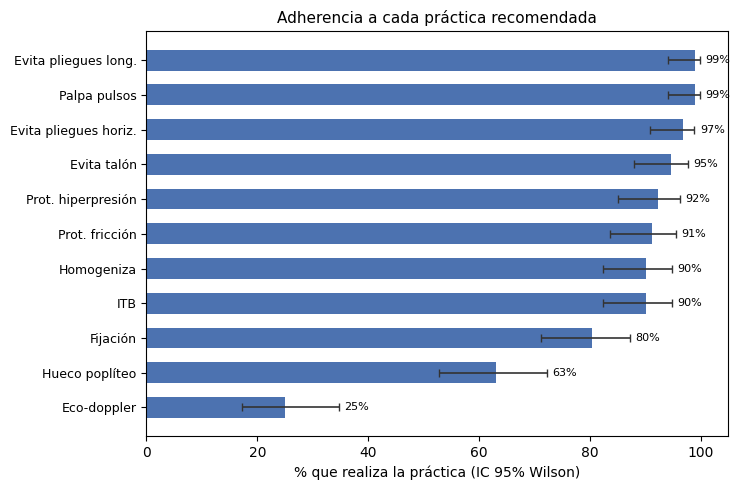

In [ ]:
# === Celda 20: barras con IC de Wilson ===
from statsmodels.stats.proportion import proportion_confint
items = {'Palpa pulsos':'palpa_pulsos','ITB':'itb','Eco-doppler':'ecodoppler',
         'Prot. fricción':'prot_friccion','Homogeniza':'homogeniza','Prot. hiperpresión':'prot_hiperpresion',
         'Hueco poplíteo':'hueco_popliteo','Evita pliegues long.':'evita_plieg_long',
         'Evita pliegues horiz.':'evita_plieg_horiz','Evita talón':'evita_talon','Fijación':'fijacion'}
rows = []
for et, c in items.items():
    s = df[c].dropna(); n = len(s); k = (s=='Sí').sum()
    lo, hi = proportion_confint(k, n, method='wilson')
    rows.append((et, k/n*100, lo*100, hi*100))
rows.sort(key=lambda r: r[1])
et, p, lo, hi = zip(*rows); yy = np.arange(len(et))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(yy, p, color='#4C72B0', height=0.6)
ax.errorbar(p, yy, xerr=[np.array(p)-np.array(lo), np.array(hi)-np.array(p)],
            fmt='none', ecolor='#333', capsize=3, lw=1.2)
ax.set_yticks(yy); ax.set_yticklabels(et, fontsize=9); ax.set_xlim(0, 105)
ax.set_xlabel('% que realiza la práctica (IC 95% Wilson)')
ax.set_title('Adherencia a cada práctica recomendada', fontsize=11)
for i, (pi, hii) in enumerate(zip(p, hi)):
    ax.text(min(hii+1, 101), i, f"{pi:.0f}%", va='center', fontsize=8)
plt.tight_layout(); plt.show()

### 🔹 Celda 21 — Calibración y discriminación del modelo
Dos diagnósticos visuales del modelo logístico. **Calibración** (izquierda): agrupa por quintiles de probabilidad predicha y compara predicho vs observado; cuanto más cerca de la diagonal, mejor se ajustan las probabilidades (complementa el test de Hosmer-Lemeshow). **Curva ROC** (derecha): representa sensibilidad frente a 1−especificidad para todos los puntos de corte; el **AUC** resume la capacidad de discriminación (0,5 = azar; 0,7–0,8 = aceptable). Aquí AUC≈0,69 confirma una discriminación modesta: el contrato explica parte, pero no todo.

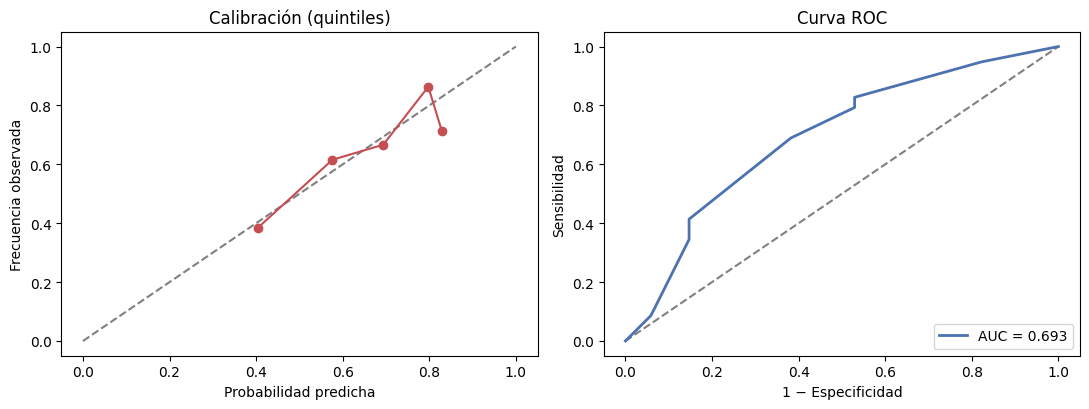

In [ ]:
# === Celda 21 (corregida): usa m_log (modelo logístico), no 'm' ===
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve

# Garantiza que m_log existe (reajuste idéntico al de la Celda 19)
m_log = smf.glm('out_hueco ~ contrato_bin + exp_bin + area_bin', data=df, family=sm.families.Binomial()).fit()

pred = np.asarray(m_log.predict()); y = df['out_hueco'].values
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

frac, mean_pred = calibration_curve(y, pred, n_bins=5, strategy='quantile')
ax[0].plot([0,1],[0,1],'--',color='gray'); ax[0].plot(mean_pred, frac, 'o-', color='#C44E52')
ax[0].set_xlabel('Probabilidad predicha'); ax[0].set_ylabel('Frecuencia observada'); ax[0].set_title('Calibración (quintiles)')

fpr, tpr, _ = roc_curve(y, pred); A = auc(fpr, tpr)
ax[1].plot([0,1],[0,1],'--',color='gray'); ax[1].plot(fpr, tpr, color='#4C72B0', lw=2, label=f'AUC = {A:.3f}')
ax[1].set_xlabel('1 − Especificidad'); ax[1].set_ylabel('Sensibilidad'); ax[1].set_title('Curva ROC'); ax[1].legend(loc='lower right')
plt.tight_layout(); plt.show()